# 03 — Root Cause Analysis
**Project:** AI-based 5G Alarm Analysis — Djezzy  
**Goal:** Identify root causes of High-Severity (HS) alarm events  
**Methods:** Evidence fusion · Causal chains · Site-risk ranking · Temporal failure patterns
---

---
## 0. Imports & Configuration
---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

from src.rca import (
    build_rca_evidence,
    build_causal_chains,
    compute_site_risk,
    compute_temporal_patterns,
    generate_rca_report,
)

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_theme(style='darkgrid', palette='muted')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 70)

PARQUET_PATH = '../data/processed/alarms_processed.parquet'
FEATURES_DIR = '../data/features/'
FIGURES_DIR  = '../reports/figures/'
REPORTS_DIR  = '../reports/'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
print('Ready.')

Ready.


### Load preprocessed alarm data

In [2]:
df = pd.read_parquet(PARQUET_PATH)
print(f'Shape: {df.shape}')

for col in ['occurrencetime_reg', 'Occurrencetime']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
if 'occurrencetime_reg' not in df.columns and 'Occurrencetime' in df.columns:
    df['occurrencetime_reg'] = df['Occurrencetime']

mapping_rules = {
    'OML Fault'                  : 'LOSS-OF-ALL CHANNEL',
    'CSL Fault'                  : 'LOSS-OF-ALL CHANNEL',
    'NodeB Unavailable'          : 'LOSS-OF-ALL CHANNEL',
    'NE Is Disconnected'         : 'Pas De Supervision',
    'GSM Cell out of Service'    : '2G cell down',
    'UMTS Cell Unavailable'      : '3G cell down',
    'UMTS Cell Setup Failed'     : '3G cell down',
    'Cell Unavailable'           : '4G cell down',
    'S1ap Link Down'             : 'LOSS-OF-ALL CHANNEL',
    'GSM Local Cell Unusable'    : '2G cell down',
    'NR DU Cell TRP Unavailable' : '5G cell down',
    'NR Cell Unavailable'        : '5G cell down',
    'gNodeB Out of Service'      : 'LOSS-OF-ALL CHANNEL',
}
HS_ALARM_NAMES = set(mapping_rules.keys())

if 'is_HS' not in df.columns:
    df['is_HS']       = df['Alarmname'].isin(HS_ALARM_NAMES)
    df['hs_category'] = df['Alarmname'].map(mapping_rules).fillna('Non-HS')

print(f"HS alarms  : {df['is_HS'].sum():,} ({df['is_HS'].mean()*100:.2f}%)")
print(f"Non-HS     : {(~df['is_HS']).sum():,}")
print(f"Alarm types: {df['Alarmname'].nunique()}")
print(f"Sites      : {df['Alarmsource'].nunique()}")
df.head(3)

Shape: (4655881, 31)
HS alarms  : 209,225 (4.49%)
Non-HS     : 4,446,656
Alarm types: 891
Sites      : 6218


,Alarmname,occurrencetime_reg,Businessaffected,codesite,Neobjectidentity,Alarmsource,clear,Clearancetime,Locationinformation,Objectidentityname,Occurrencetime,R Server Id,Severity,Netype,Productname,Status,Type,Clearing Status,Remote Last Update,Logserialnumber,duration_min,is_cleared,hour,day_of_week,date,month,year,is_night,is_weekend,is_HS,hs_category
0,Adjacent Node IP Address Ping Failure,2025-02-22 22:31:46,nan,None,NE=9077,ROR03,Cleared,NaT,"Subrack No.=0, Slot No.=23, Adjacent Node IP Address=10.75.22.74, ...",ROR03,2025-02-22 22:31:46+01:00,1,Major,BSC6910 GU,Mobile,Unacknowledged and uncleared Alarm,Trunk system,Cleared,2025-02-22 22:35:00,583576234,NaN,False,22.0,Saturday,2025-02-22,2.0,2025.0,False,True,False,Non-HS
1,Parallel Alarm Exceeds the Limit,2025-02-19 07:11:24,yes,None,OS=1,OSS,Cleared,NaT,"RuleID=1980, Source Alarm Information=",OSS,2025-02-19 07:11:24+01:00,1,Major,OSS,NMS,Unacknowledged and uncleared Alarm,Processing error,Cleared,2025-02-19 07:15:00,583246673,NaN,False,7.0,Wednesday,2025-02-19,2.0,2025.0,False,False,False,Non-HS
2,Parallel Alarm Exceeds the Limit,2025-02-19 07:11:26,yes,None,OS=1,OSS,Cleared,NaT,"RuleID=1980, Source Alarm Information=",OSS,2025-02-19 07:11:26+01:00,1,Major,OSS,NMS,Unacknowledged and uncleared Alarm,Processing error,Cleared,2025-02-19 07:15:00,583246678,NaN,False,7.0,Wednesday,2025-02-19,2.0,2025.0,False,False,False,Non-HS


### Load pre-computed correlation features

In [3]:
precursor_df   = pd.read_csv(FEATURES_DIR + 'precursor_rankings.csv')
cooc_pairs_df  = pd.read_csv(FEATURES_DIR + 'cooccurrence_pairs.csv')
assoc_rules_df = pd.read_csv(FEATURES_DIR + 'association_rules.csv')
net_metrics_df = pd.read_csv(FEATURES_DIR + 'network_metrics.csv')
lag_df         = pd.read_csv(FEATURES_DIR + 'temporal_lag_correlations.csv')
jaccard_df     = pd.read_csv(FEATURES_DIR + 'jaccard_similarity.csv', index_col=0)

print(f'Precursor rankings : {len(precursor_df):,} rows')
print(f'Co-occurrence pairs: {len(cooc_pairs_df):,} rows')
print(f'Association rules  : {len(assoc_rules_df):,} rows')
print(f'Network metrics    : {len(net_metrics_df):,} nodes')
print(f'Lag correlations   : {len(lag_df):,} rows')

Precursor rankings : 468 rows
Co-occurrence pairs: 780 rows
Association rules  : 50 rows
Network metrics    : 40 nodes
Lag correlations   : 7,500 rows


---
## 1. Evidence Fusion — Composite RCA Scoring
> Combine **precursor frequency**, **Jaccard co-occurrence**, **association-rule lift**, and **PageRank centrality** into a single ranked evidence table per HS category.

In [4]:
evidence_df = build_rca_evidence(
    precursor_df       = precursor_df,
    cooc_pairs_df      = cooc_pairs_df,
    assoc_rules_df     = assoc_rules_df,
    network_metrics_df = net_metrics_df,
    w_precursor=0.40, w_jaccard=0.20, w_lift=0.25, w_pagerank=0.15,
)
print(f'Evidence table shape: {evidence_df.shape}')
evidence_df.head(10)

Evidence table shape: (468, 8)


,alarm,hs_category,frequency,precursor_score,jaccard_score,lift_score,pagerank_score,composite_score
0,Adjacent Node IP Address Ping Failure,3G cell down,0.2760,0.978014,0.703910,0.0,0.881094,0.664152
1,SCTP Link Fault,3G cell down,0.2822,1.000000,0.219431,0.0,0.367793,0.499055
2,Adjacent Node IP Address Ping Failure,LOSS-OF-ALL CHANNEL,0.0752,0.265957,0.703910,0.0,0.881094,0.379329
3,The Data Transmission Channel Between the Trace Server and the NE ...,Pas De Supervision,0.0650,0.229787,1.000000,0.0,0.483005,0.364366
4,Adjacent Node IP Address Ping Failure,2G cell down,0.0500,0.176596,0.703910,0.0,0.881094,0.343585
5,Cell Outage,Pas De Supervision,0.0586,0.207092,0.580355,0.0,0.348576,0.251194
6,3G PS Call Setup Success Rate,3G cell down,0.0182,0.063830,0.700831,0.0,0.465759,0.235562
7,3G CS Call Drop Rate,3G cell down,0.0140,0.048936,0.700831,0.0,0.476422,0.231204
8,RF Unit Maintenance Link Failure,4G cell down,0.0470,0.165957,0.337082,0.0,0.638241,0.229536
9,SCTP Link Fault,LOSS-OF-ALL CHANNEL,0.0840,0.297163,0.219431,0.0,0.367793,0.217920


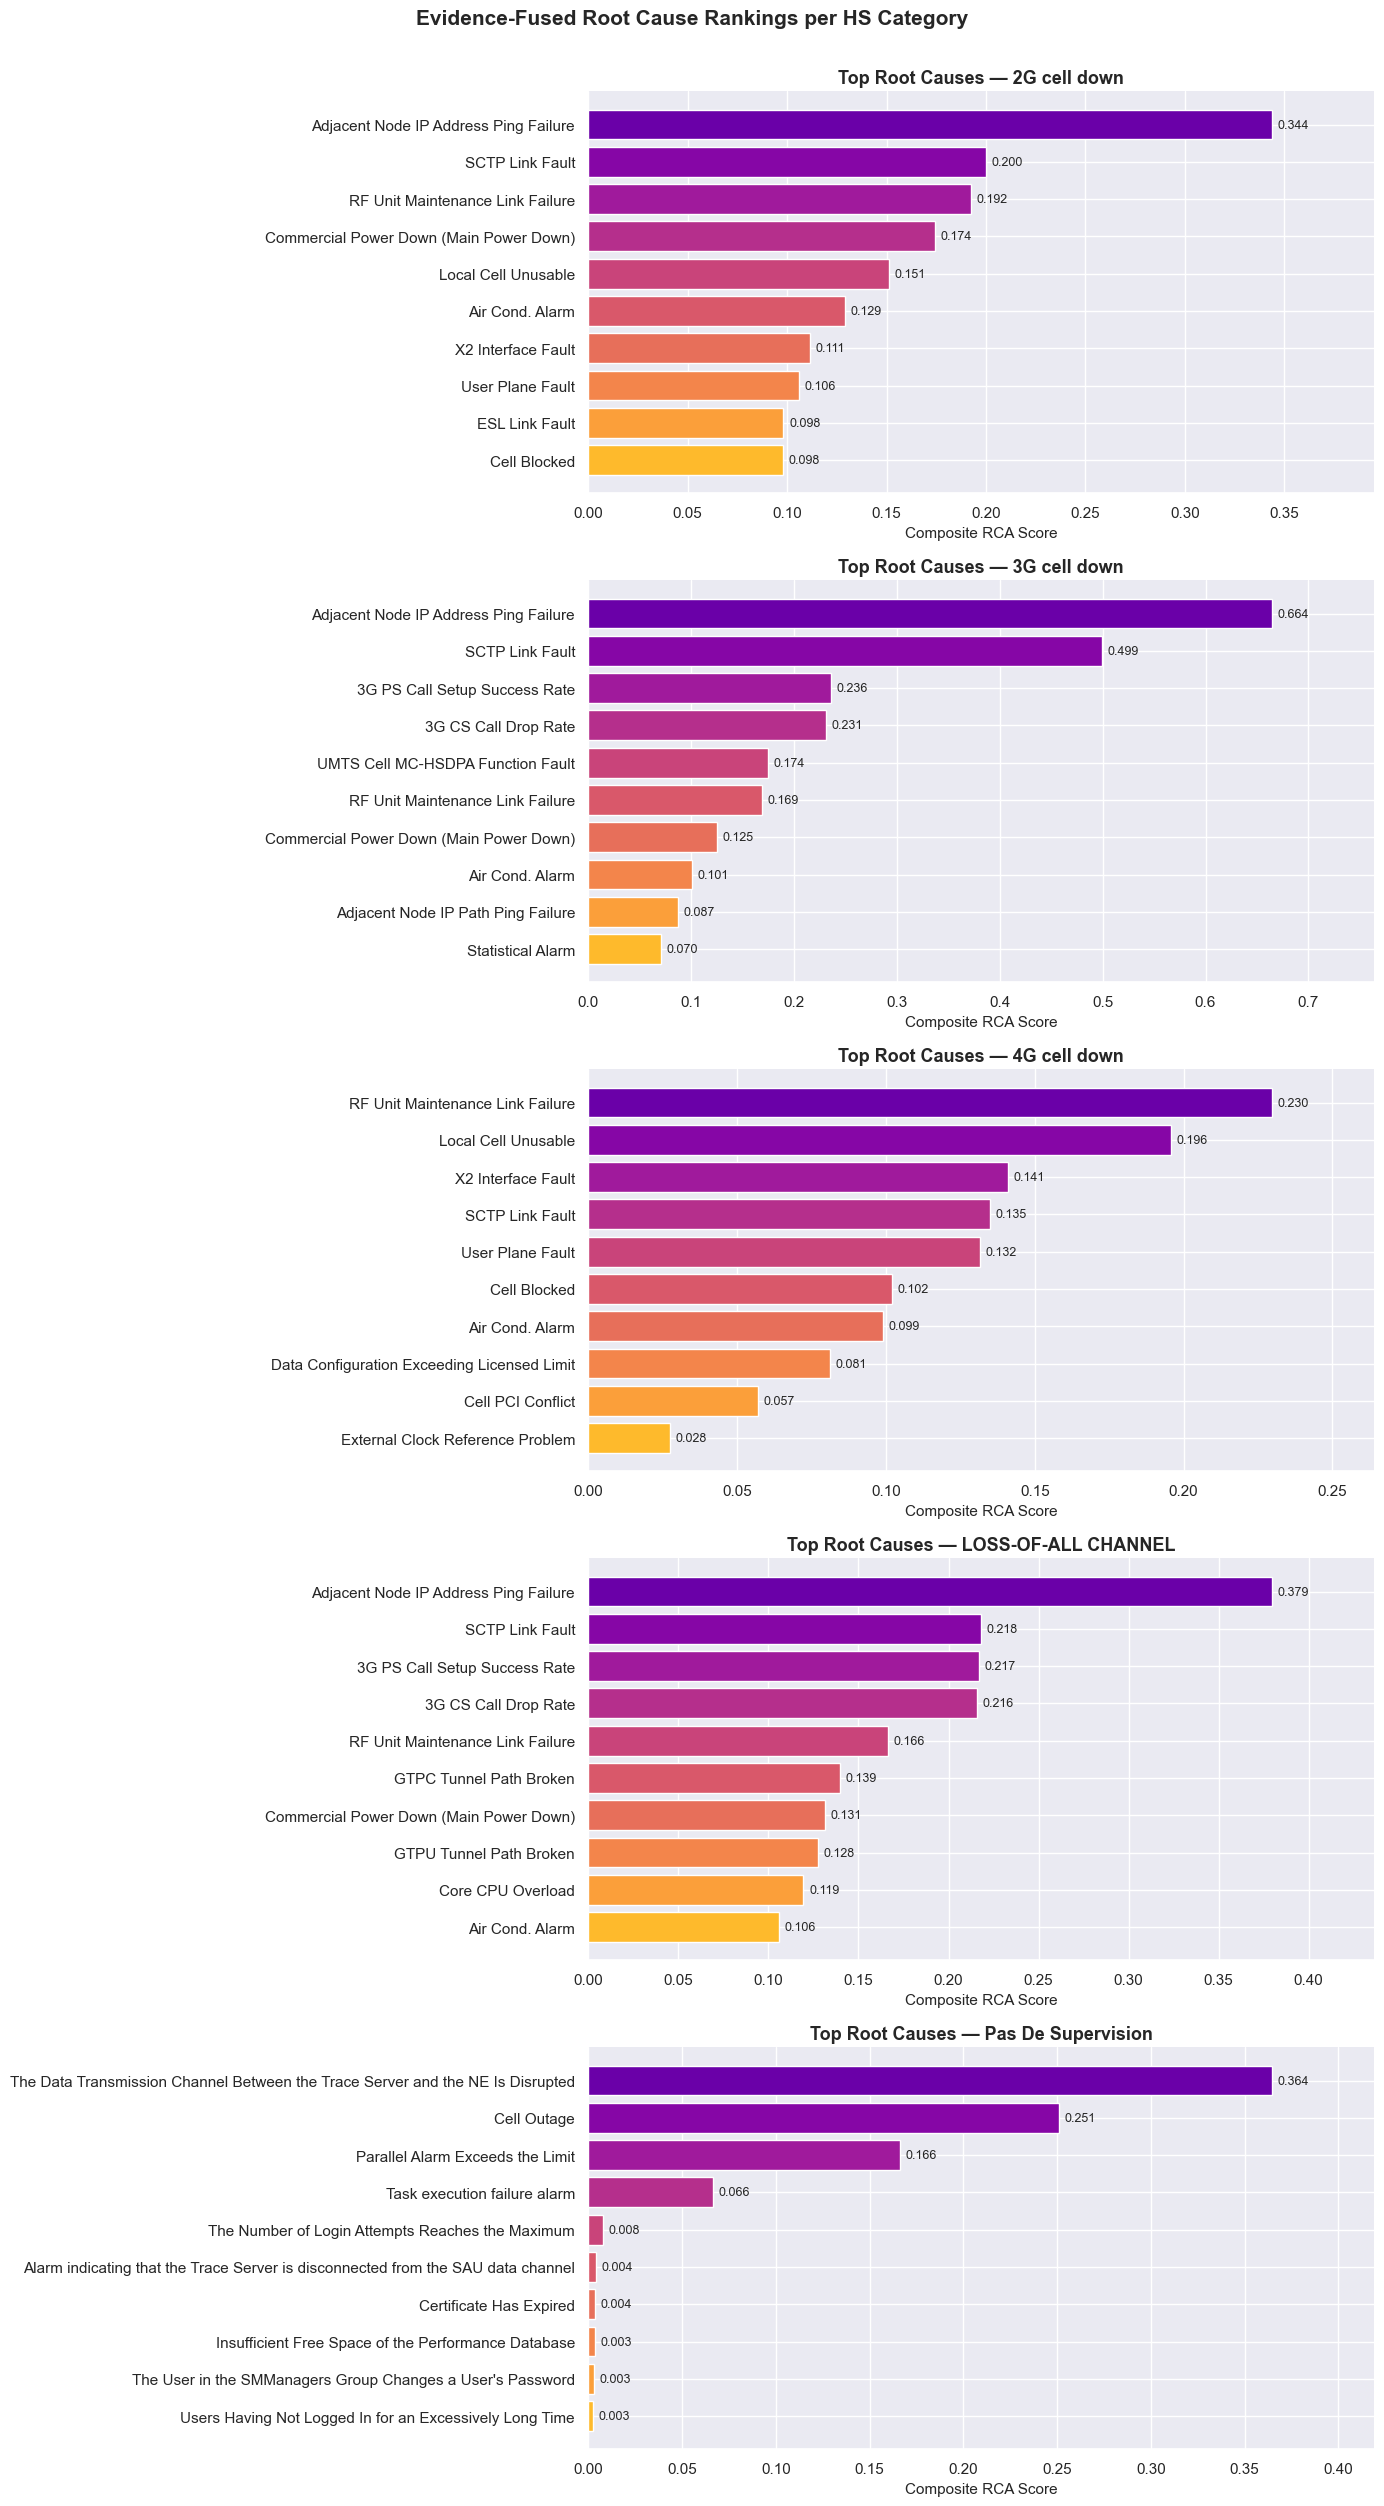

In [5]:
hs_cats = sorted(evidence_df['hs_category'].unique())
n_cats  = len(hs_cats)

fig, axes = plt.subplots(n_cats, 1, figsize=(14, 5 * n_cats), squeeze=False)
for idx, cat in enumerate(hs_cats):
    sub = evidence_df[evidence_df['hs_category'] == cat].head(10)
    ax  = axes[idx, 0]
    colors = plt.cm.plasma(np.linspace(0.2, 0.85, len(sub)))
    bars = ax.barh(sub['alarm'], sub['composite_score'], color=colors)
    ax.invert_yaxis()
    ax.set_xlabel('Composite RCA Score', fontsize=11)
    ax.set_title(f'Top Root Causes — {cat}', fontsize=13, fontweight='bold')
    ax.bar_label(bars, fmt='{:.3f}', padding=4, fontsize=9)
    ax.set_xlim(0, sub['composite_score'].max() * 1.15)
    sns.despine(ax=ax, left=True)

plt.suptitle('Evidence-Fused Root Cause Rankings per HS Category',
             fontsize=15, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'rca_evidence_rankings.png', dpi=150, bbox_inches='tight')
plt.show()

### Score Breakdown by Evidence Source

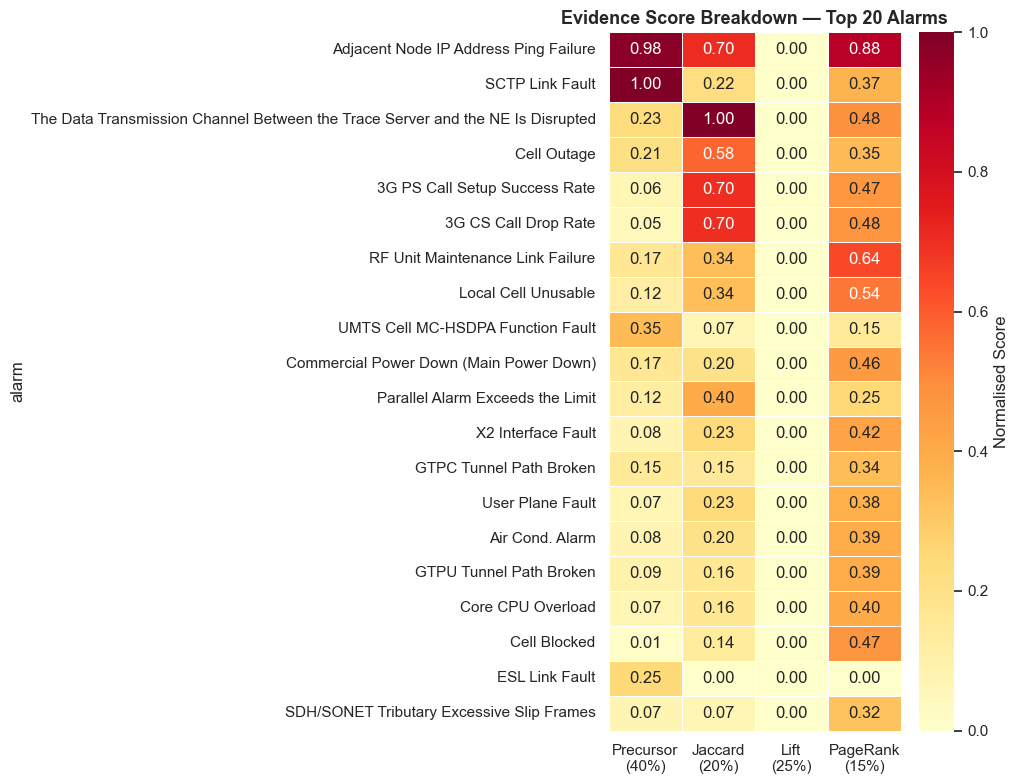

In [6]:
top20      = evidence_df.drop_duplicates('alarm').head(20).copy()
score_cols = ['precursor_score', 'jaccard_score', 'lift_score', 'pagerank_score']
xlabels    = ['Precursor\n(40%)', 'Jaccard\n(20%)', 'Lift\n(25%)', 'PageRank\n(15%)']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(top20.set_index('alarm')[score_cols],
            cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=.4, ax=ax, xticklabels=xlabels,
            cbar_kws={'label': 'Normalised Score'})
ax.set_title('Evidence Score Breakdown — Top 20 Alarms', fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'rca_score_breakdown_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Causal Chain Reconstruction
> Trace multi-hop propagation paths: upstream alarms → direct precursor → HS event.

In [7]:
all_chains = []
for cat in hs_cats:
    chains = build_causal_chains(
        lag_df=lag_df, precursor_df=precursor_df,
        hs_category=cat, top_n_precursors=5,
        top_n_lag=3, max_lag_hours=6,
    )
    all_chains.extend(chains)

chains_df = pd.DataFrame(all_chains).dropna(subset=['root'])
print(f'Causal chains found: {len(chains_df)}')
chains_df.head(15)

Causal chains found: 51


,root,intermediate,terminal,correlation,lag_hours
0,RF Unit RX Channel RTWP/RSSI Unbalanced,SCTP Link Fault,2G cell down,0.1921,1.0
1,RF Unit RX Channel RTWP/RSSI Unbalanced,SCTP Link Fault,2G cell down,0.1911,3.0
2,RF Unit RX Channel RTWP/RSSI Unbalanced,SCTP Link Fault,2G cell down,0.1886,2.0
5,RF Unit RX Channel RTWP/RSSI Unbalanced,Adjacent Node IP Address Ping Failure,2G cell down,0.2767,1.0
6,X2 Interface Fault,Adjacent Node IP Address Ping Failure,2G cell down,0.2699,1.0
7,Cell RX Channel Interference Noise Power Unbalanced,Adjacent Node IP Address Ping Failure,2G cell down,0.2651,1.0
8,RF Unit RX Channel RTWP/RSSI Unbalanced,Commercial Power Down (Main Power Down),2G cell down,0.4187,1.0
9,RF Unit RX Channel RTWP/RSSI Unbalanced,Commercial Power Down (Main Power Down),2G cell down,0.3963,2.0
10,RF Unit RX Channel RTWP/RSSI Unbalanced,Commercial Power Down (Main Power Down),2G cell down,0.3837,3.0
11,RF Unit RX Channel RTWP/RSSI Unbalanced,SCTP Link Fault,3G cell down,0.1921,1.0


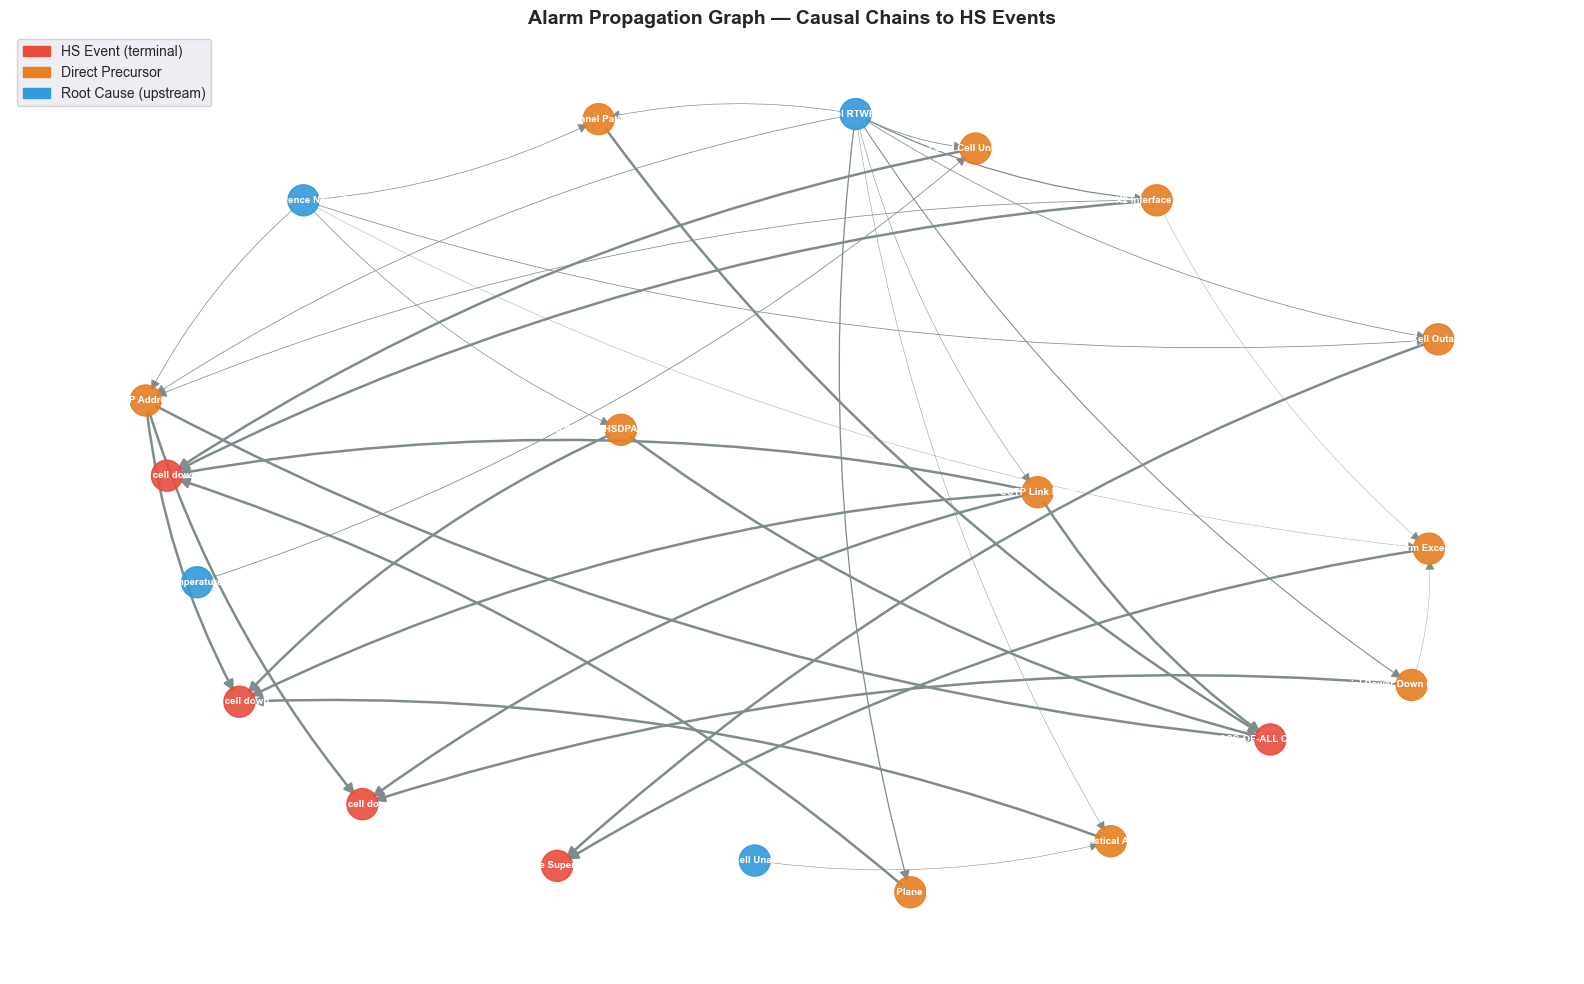

Graph: 20 nodes, 36 edges


In [8]:
DG = nx.DiGraph()
for _, row in chains_df.iterrows():
    w = float(row['correlation']) if pd.notna(row['correlation']) else 0.1
    DG.add_edge(row['root'], row['intermediate'], weight=w)
    DG.add_edge(row['intermediate'], row['terminal'], weight=0.9)

hs_set   = set(hs_cats)
prec_set = set(chains_df['intermediate'].unique())
color_map = ['#e74c3c' if n in hs_set else '#e67e22' if n in prec_set else '#3498db'
             for n in DG.nodes()]
edge_weights = [DG[u][v]['weight'] * 2 for u, v in DG.edges()]

pos = nx.spring_layout(DG, seed=42, k=2.0)
fig, ax = plt.subplots(figsize=(16, 10))
nx.draw_networkx_nodes(DG, pos, node_color=color_map, node_size=500, ax=ax, alpha=0.9)
nx.draw_networkx_edges(DG, pos, width=edge_weights, edge_color='#7f8c8d',
                       arrows=True, arrowsize=15, ax=ax,
                       connectionstyle='arc3,rad=0.1')
nx.draw_networkx_labels(DG, pos, font_size=7, ax=ax,
                        font_color='white', font_weight='bold')
from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='HS Event (terminal)'),
          Patch(color='#e67e22', label='Direct Precursor'),
          Patch(color='#3498db', label='Root Cause (upstream)')]
ax.legend(handles=legend, loc='upper left', framealpha=0.85, fontsize=10)
ax.set_title('Alarm Propagation Graph — Causal Chains to HS Events',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'rca_causal_graph.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Graph: {DG.number_of_nodes()} nodes, {DG.number_of_edges()} edges')

---
## 3. Precursor Deep-Dive per HS Category
> Non-HS alarms most likely to **precede** each HS event within a 60-minute window on the same site.

In [9]:
for cat in hs_cats:
    sub = precursor_df[precursor_df['hs_category'] == cat].head(12)
    if sub.empty:
        continue
    fig = px.bar(
        sub, x='frequency', y='precursor_alarm', orientation='h',
        color='frequency', color_continuous_scale='Oranges',
        title=f'Top Precursor Alarms — {cat}',
        labels={'frequency': 'Precursor Frequency', 'precursor_alarm': 'Alarm'},
        text='frequency',
    )
    fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
    fig.update_yaxes(autorange='reversed')
    fig.update_layout(coloraxis_showscale=False, height=420,
                      margin=dict(l=300, r=40, t=50, b=40))
    fig.show()

---
## 4. Site-Level Risk Ranking
> Which network sites carry the highest HS alarm burden? Risk score = weighted sum of HS count, HS rate, and alarm-type diversity.

In [10]:
site_risk_df = compute_site_risk(df, top_n_sites=25)
print(f'Site risk table: {site_risk_df.shape}')
site_risk_df.head(10)

Site risk table: (25, 7)


,Alarmsource,total_alarms,hs_count,unique_alarms,hs_rate,unique_hs_types,risk_score
0,ROR03,54793,19102,105,0.348621,6,0.836916
1,RAL03,44266,10984,61,0.248136,6,0.584961
2,RCN03,28640,9589,83,0.334811,6,0.582487
3,Annaba RNC,106206,13485,24,0.126970,3,0.502839
4,RLI03,74794,9154,80,0.122389,6,0.487675
5,UNC02_Annaba,7496,5726,22,0.763874,1,0.483213
6,OSS,111119,14461,43,0.130140,1,0.462964
7,UNC02_Tlemcen,10348,5394,19,0.521260,1,0.379240
8,BA06H,641,398,21,0.620905,3,0.354269
9,BA02H,893,529,32,0.592385,3,0.346497


In [11]:
site_col   = site_risk_df.columns[0]
top20s     = site_risk_df.head(20)

fig = px.bar(
    top20s, x='risk_score', y=site_col, orientation='h',
    color='hs_rate', color_continuous_scale='Reds',
    title='Top-20 High-Risk Network Sites',
    labels={'risk_score': 'Risk Score', site_col: 'Site', 'hs_rate': 'HS Rate'},
    text='hs_count',
)
fig.update_traces(texttemplate='%{text} HS', textposition='outside')
fig.update_yaxes(autorange='reversed')
fig.update_layout(height=550, margin=dict(l=280, r=60, t=50, b=40))
fig.show()

In [12]:
fig = px.scatter(
    site_risk_df,
    x='total_alarms', y='hs_rate',
    size='hs_count', color='risk_score',
    color_continuous_scale='plasma',
    hover_name=site_col,
    title='Site Risk: HS Rate vs Total Alarms  (bubble = HS count)',
    labels={'total_alarms': 'Total Alarms', 'hs_rate': 'HS Rate',
            'hs_count': 'HS Count', 'risk_score': 'Risk Score'},
    size_max=40,
)
fig.update_layout(height=500)
fig.show()

---
## 5. Temporal Failure Patterns
> When do HS events peak? Heatmaps reveal the riskiest hours and weekdays per category.

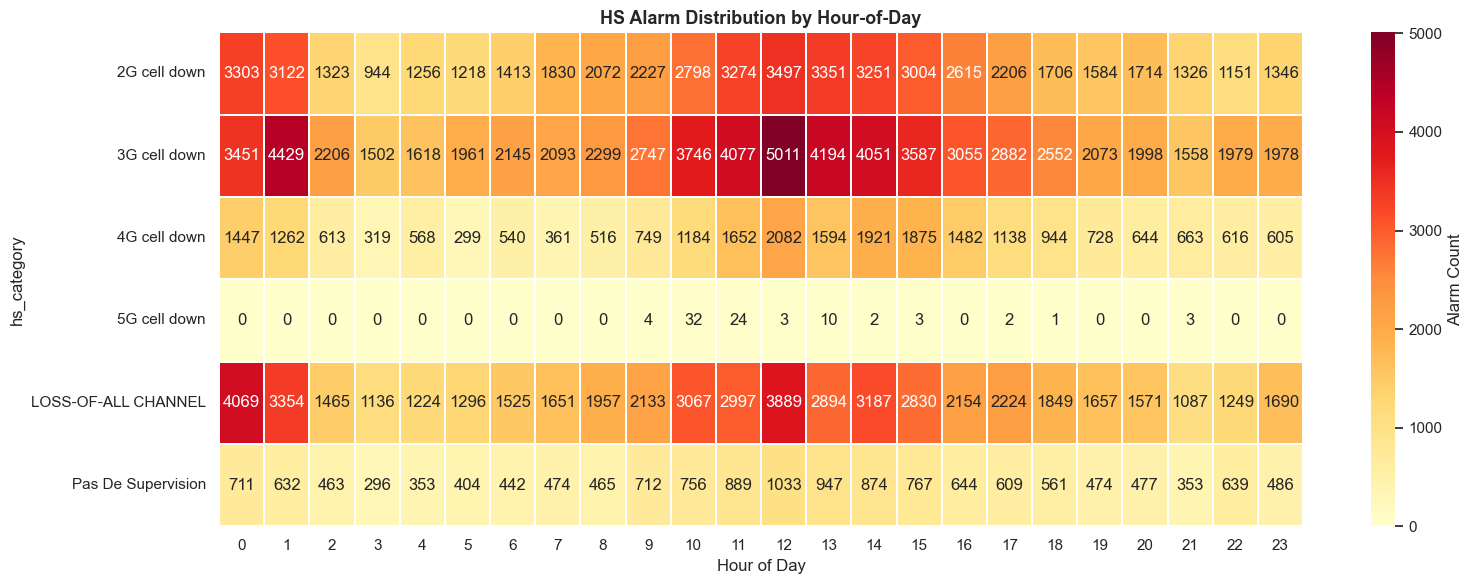

In [13]:
hourly_df, daily_df = compute_temporal_patterns(df)

pivot_hourly = hourly_df.pivot(index='hs_category', columns='hour', values='count').fillna(0)
fig, ax = plt.subplots(figsize=(16, max(4, len(hs_cats) * 1.2)))
sns.heatmap(pivot_hourly, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=.3, ax=ax, cbar_kws={'label': 'Alarm Count'})
ax.set_title('HS Alarm Distribution by Hour-of-Day', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'rca_hourly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

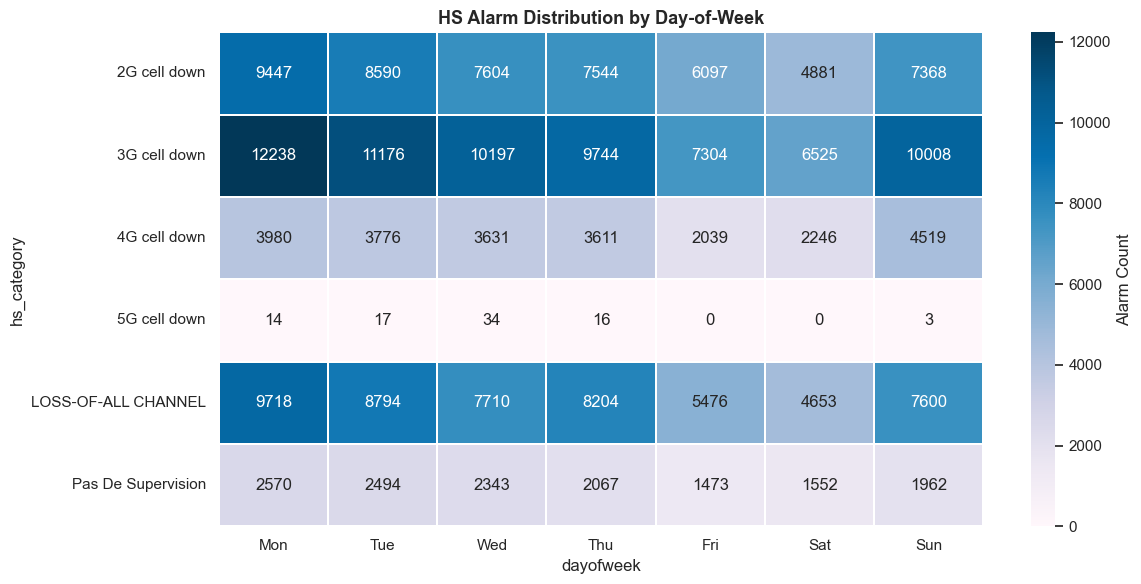

In [14]:
day_names   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot_daily = (daily_df
               .pivot(index='hs_category', columns='dayofweek', values='count')
               .fillna(0)
               .rename(columns={i: day_names[i] for i in range(7)}))

fig, ax = plt.subplots(figsize=(12, max(4, len(hs_cats) * 1.2)))
sns.heatmap(pivot_daily, cmap='PuBu', annot=True, fmt='.0f',
            linewidths=.3, ax=ax, cbar_kws={'label': 'Alarm Count'})
ax.set_title('HS Alarm Distribution by Day-of-Week', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'rca_daily_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
fig = px.line(
    hourly_df, x='hour', y='count',
    color='hs_category', markers=True,
    title='HS Alarm Volume by Hour of Day (per Category)',
    labels={'hour': 'Hour of Day', 'count': 'Alarm Count', 'hs_category': 'Category'},
)
fig.update_layout(height=450, xaxis=dict(dtick=2))
fig.show()

---
## 6. Network Centrality & Community Analysis
> PageRank and betweenness centrality reveal the most **structurally influential** alarms in the propagation network.

In [16]:
alarm_col_name = 'Unnamed: 0' if 'Unnamed: 0' in net_metrics_df.columns else net_metrics_df.columns[0]
net_df = net_metrics_df.rename(columns={alarm_col_name: 'alarm'})
net_df = net_df.sort_values('pagerank', ascending=False)
print('Top-10 alarms by PageRank:')
net_df.head(10)

Top-10 alarms by PageRank:


,alarm,degree_centrality,betweenness_centrality,pagerank,community
0,NodeB Unavailable,0.153846,0.022942,0.065126,0
1,UMTS Cell Unavailable,0.153846,0.000000,0.064123,0
2,Adjacent Node IP Address Ping Failure,0.179487,0.004049,0.057881,0
3,GSM Cell out of Service,0.282051,0.255061,0.043621,0
4,RF Unit Maintenance Link Failure,0.102564,0.137652,0.043084,1
5,Local Cell Unusable,0.076923,0.005398,0.037211,1
6,The Data Transmission Channel Between the Trace Server and the NE ...,0.076923,0.000000,0.033626,4
7,NE Is Disconnected,0.076923,0.000000,0.033244,4
8,3G CS Call Drop Rate,0.051282,0.000000,0.033224,5
9,Cell Blocked,0.128205,0.105263,0.032961,1


In [17]:
fig = px.scatter(
    net_df,
    x='betweenness_centrality', y='pagerank',
    size='degree_centrality', color='community',
    hover_name='alarm', text='alarm',
    title='Alarm Network: PageRank vs Betweenness Centrality',
    labels={'betweenness_centrality': 'Betweenness',
            'pagerank': 'PageRank', 'community': 'Community'},
    size_max=30, color_continuous_scale='Turbo',
)
fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(height=520)
fig.show()

In [18]:
comm_counts = net_df.groupby('community').size().reset_index(name='n_alarms')
fig = px.bar(comm_counts, x='community', y='n_alarms',
             color='n_alarms', color_continuous_scale='Blues',
             title='Alarm Communities (Greedy Modularity)',
             labels={'community': 'Community ID', 'n_alarms': 'Number of Alarms'})
fig.update_layout(height=380, coloraxis_showscale=False)
fig.show()

print('Top alarm per community (by PageRank):')
top_per_comm = net_df.loc[net_df.groupby('community')['pagerank'].idxmax()]
print(top_per_comm[['alarm','community','pagerank','betweenness_centrality']].to_string(index=False))

Top alarm per community (by PageRank):
                                                                         alarm  community  pagerank  betweenness_centrality
                                                             NodeB Unavailable          0  0.065126                0.022942
                                              RF Unit Maintenance Link Failure          1  0.043084                0.137652
                                       Commercial Power Down (Main Power Down)          2  0.032004                0.001350
                                                                S1ap Link Down          3  0.030163                0.000000
The Data Transmission Channel Between the Trace Server and the NE Is Disrupted          4  0.033626                0.000000
                                                          3G CS Call Drop Rate          5  0.033224                0.000000
                                                            X2 Interface Fault          6  0.

---
## 7. Association Rule Insights
> High-lift rules expose reliable **co-occurrence patterns** that precede HS events.

In [19]:
top_rules = assoc_rules_df.nlargest(20, 'lift').copy()
top_rules['rule'] = top_rules['antecedents_str'] + ' → ' + top_rules['consequents_str']

fig = px.scatter(
    top_rules, x='support', y='confidence',
    size='lift', color='lift', color_continuous_scale='Plasma',
    hover_name='rule',
    title='Association Rules: Support vs Confidence  (bubble = Lift)',
    labels={'support': 'Support', 'confidence': 'Confidence', 'lift': 'Lift'},
    size_max=45,
)
fig.update_layout(height=500)
fig.show()

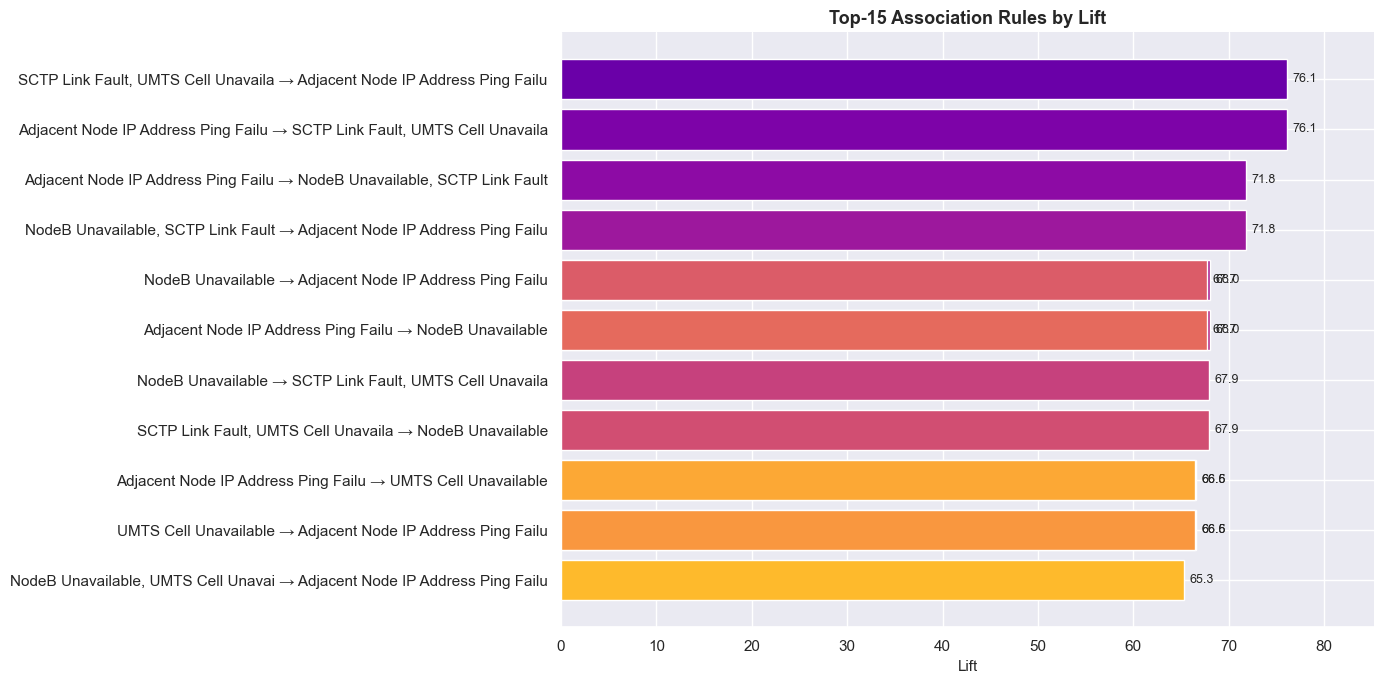

In [20]:
top15 = assoc_rules_df.nlargest(15, 'lift').copy()
top15['rule'] = (top15['antecedents_str'].str[:35] + ' → ' +
                 top15['consequents_str'].str[:35])

fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.plasma(np.linspace(0.2, 0.85, len(top15)))
bars   = ax.barh(top15['rule'], top15['lift'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Lift', fontsize=11)
ax.set_title('Top-15 Association Rules by Lift', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='{:.1f}', padding=4, fontsize=9)
ax.set_xlim(0, top15['lift'].max() * 1.12)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'rca_association_rules.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. RCA Summary Table
> Consolidated top-3 root causes per HS category with multi-source evidence.

In [21]:
summary_rows = []
for cat in hs_cats:
    sub = evidence_df[evidence_df['hs_category'] == cat].head(3)
    for rank, (_, row) in enumerate(sub.iterrows(), 1):
        prec_sub = precursor_df[
            (precursor_df['hs_category'] == cat) &
            (precursor_df['precursor_alarm'] == row['alarm'])
        ]
        prec_count = int(prec_sub['count'].values[0]) if len(prec_sub) else 0

        lift_sub   = assoc_rules_df[
            assoc_rules_df['antecedents_str'].str.contains(row['alarm'][:20], regex=False, na=False)
        ]
        best_lift  = round(lift_sub['lift'].max(), 1) if len(lift_sub) else '-'

        summary_rows.append({
            'HS Category'      : cat,
            'Rank'             : rank,
            'Root Cause Alarm' : row['alarm'],
            'Composite Score'  : f"{row['composite_score']:.3f}",
            'Precursor Count'  : prec_count,
            'Best Lift'        : best_lift,
            'PageRank Score'   : f"{row['pagerank_score']:.3f}",
        })

summary_df = pd.DataFrame(summary_rows)
summary_df

,HS Category,Rank,Root Cause Alarm,Composite Score,Precursor Count,Best Lift,PageRank Score
0,2G cell down,1,Adjacent Node IP Address Ping Failure,0.344,250,76.1,0.881
1,2G cell down,2,SCTP Link Fault,0.200,356,76.1,0.368
2,2G cell down,3,RF Unit Maintenance Link Failure,0.192,104,-,0.638
3,3G cell down,1,Adjacent Node IP Address Ping Failure,0.664,1380,76.1,0.881
4,3G cell down,2,SCTP Link Fault,0.499,1411,76.1,0.368
5,3G cell down,3,3G PS Call Setup Success Rate,0.236,91,-,0.466
6,4G cell down,1,RF Unit Maintenance Link Failure,0.230,235,-,0.638
7,4G cell down,2,Local Cell Unusable,0.196,167,-,0.542
8,4G cell down,3,X2 Interface Fault,0.141,111,-,0.422
9,LOSS-OF-ALL CHANNEL,1,Adjacent Node IP Address Ping Failure,0.379,376,76.1,0.881


---
## 9. Save Artefacts & Markdown Report

In [22]:
evidence_df.to_csv(FEATURES_DIR + 'rca_evidence.csv', index=False)
site_risk_df.to_csv(FEATURES_DIR + 'rca_site_risk.csv', index=False)
chains_df.to_csv(FEATURES_DIR + 'rca_causal_chains.csv', index=False)
print('Saved → rca_evidence.csv, rca_site_risk.csv, rca_causal_chains.csv')

report = generate_rca_report(
    evidence_df  = evidence_df,
    chains       = all_chains,
    site_risk_df = site_risk_df,
    output_path  = REPORTS_DIR + 'rca_report.md',
)
print('Saved → rca_report.md')
print()
print(report[:1000])

Saved → rca_evidence.csv, rca_site_risk.csv, rca_causal_chains.csv
Saved → rca_report.md

# Root Cause Analysis Report
**Project:** AI-based 5G Alarm Analysis — Djezzy  
**Phase:** 03 — Root Cause Analysis  

---
## 1. Top Root Causes per HS Category

### 3G cell down
| Rank | Alarm | Composite Score |
|------|-------|-----------------|
| 1 | Adjacent Node IP Address Ping Failure | 0.664 |
| 2 | SCTP Link Fault | 0.499 |
| 3 | 3G PS Call Setup Success Rate | 0.236 |
| 4 | 3G CS Call Drop Rate | 0.231 |
| 5 | UMTS Cell MC-HSDPA Function Fault | 0.174 |

### LOSS-OF-ALL CHANNEL
| Rank | Alarm | Composite Score |
|------|-------|-----------------|
| 1 | Adjacent Node IP Address Ping Failure | 0.379 |
| 2 | SCTP Link Fault | 0.218 |
| 3 | 3G PS Call Setup Success Rate | 0.217 |
| 4 | 3G CS Call Drop Rate | 0.216 |
| 5 | RF Unit Maintenance Link Failure | 0.166 |

### Pas De Supervision
| Rank | Alarm | Composite Score |
|------|-------|-----------------|
| 1 | The Data Transmission Channel